In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 1. Load and Inspect the Data

#We begin by loading the Fitbit daily activity dataset and inspecting its structure.


In [3]:
df = pd.read_csv('/Users/nimatsheringlama/Downloads/dailyActivity_merged.csv')

In [4]:
df.head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863
5,1503960366,4/17/2016,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728
6,1503960366,4/18/2016,13019,8.59,8.59,0.0,3.25,0.64,4.71,0.0,42,16,233,1149,1921
7,1503960366,4/19/2016,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035
8,1503960366,4/20/2016,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786
9,1503960366,4/21/2016,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775


In [5]:
## 2. Data Cleaning

# We check for duplicates, missing values, and ensure the date format is correct for further analysis.


In [87]:
print(df['Id'].nunique())
print(df.shape)               # Rows and columns          
print(df.info())              # Data types and non-null counts

33
(940, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyAc

In [7]:
# As per our analysis of the data. The activity date is an object, let's change
# that into a datetime and check for duplicates and null values. We also found that we have 
# 33 unique users, which is great for sample data.

In [8]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [11]:
# Since there is no null values and duplicates the data looks good. 
# Now let's check the weekends vs weekday activity. But first we have to create the day of 
# the week column to see which days are the user most active.

In [12]:
# Create DayOfWeek column
df['DayOfWeek'] = df['ActivityDate'].dt.day_name()
# Create DayType
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# Group and summarize
activity_summary = df.groupby('DayType')[['TotalSteps', 'VeryActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']].mean().round(2)
activity_summary

,TotalSteps,VeryActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
DayType,,,,,
Weekday,7668.70,21.24,193.54,996.18,2301.52
Weekend,7550.57,20.96,190.76,977.11,2309.55


In [17]:
# Cheking to see the days of week so that we can get a sense of which day the users
# are more active

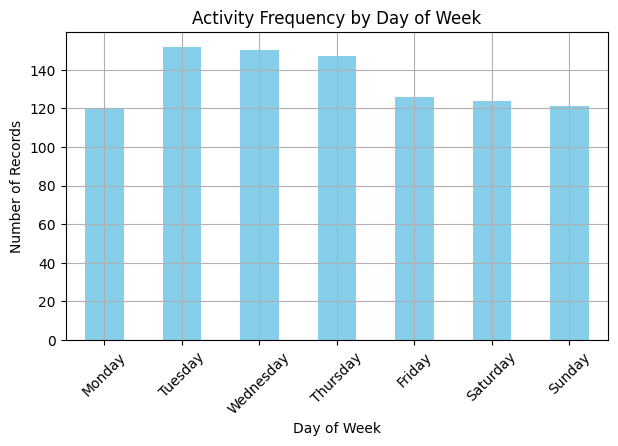

In [18]:
# Ordered list of weekdays
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot properly ordered frequencies
df['DayOfWeek'].value_counts().reindex(weekdays).plot(kind='bar', color='skyblue', figsize=(7,4))
plt.title('Activity Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [19]:
# From above bar chart we can see that most users are active during the weekdays of 
# Tuesday, Wednesday and Thursday. Hence, we can nudge users to be more active for our marketing 
# campaign on other days.

In [14]:
# Let's see the calories vs steps and the correlation.

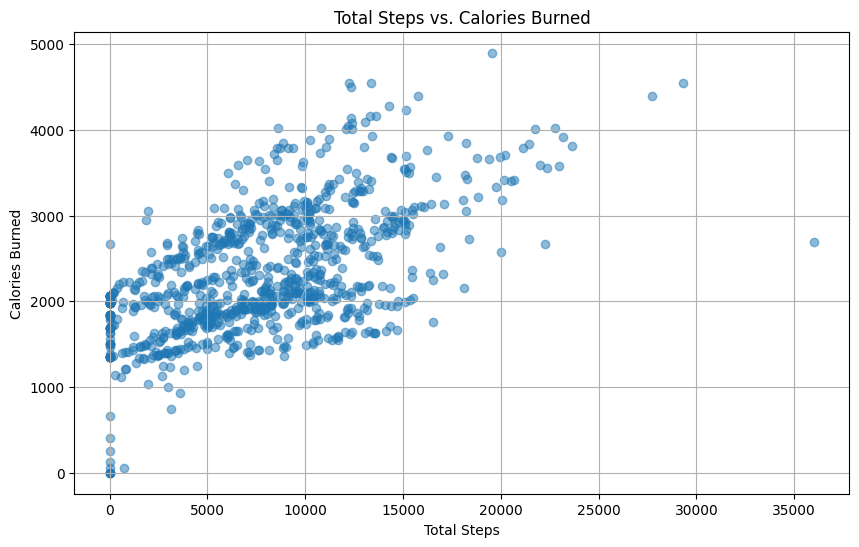

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(df['TotalSteps'], df['Calories'], alpha=0.5)
plt.title('Total Steps vs. Calories Burned')
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.grid(True)
plt.show()

In [ ]:
# Now lets check how many different type of users are there percentage wise (active, sedentary...) in a pie chart.

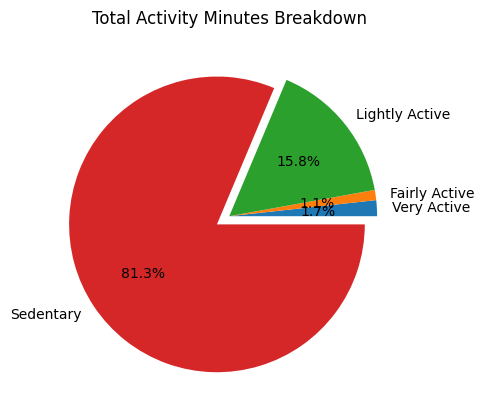

In [97]:
values = [
    df['VeryActiveMinutes'].sum(),
    df['FairlyActiveMinutes'].sum(),
    df['LightlyActiveMinutes'].sum(),
    df['SedentaryMinutes'].sum()
]

# Labels for the pie chart
labels = ['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary']

# Create pie chart
plt.pie(values, labels=labels, autopct='%.1f%%', explode=[0, 0, 0, 0.1])
plt.title('Total Activity Minutes Breakdown')
plt.show()

In [ ]:
#From the above pie chart we can see that most of the user is sedentary which is about 80%, fairly active 
# is 1.1 close to very active (1.7) and lightly active is 15.8%.

In [51]:
sleepDay_df = pd.read_csv("/Users/nimatsheringlama/Downloads/sleepDay_merged.csv")

In [99]:
print(sleepDay_df['Id'].nunique())
sleepDay_df.head()

24


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,DayOfWeek
0,1503960366,2016-04-12,1,327,346,Tuesday
1,1503960366,2016-04-13,2,384,407,Wednesday
2,1503960366,2016-04-15,1,412,442,Friday
3,1503960366,2016-04-16,2,340,367,Saturday
4,1503960366,2016-04-17,1,700,712,Sunday


In [101]:
# Though there are only 24 different users/samples for sleep data it doesn't meet the threshold of 30. But we
# will still be using to get general idea of sleep activity.
# Converting the date column to only include date and also adding a day of the week in it.

In [71]:
# Convert SleepDay to datetime and strip time part by keeping only the date
sleepDay_df['SleepDay'] = pd.to_datetime(sleepDay_df['SleepDay'], format='%m/%d/%Y %I:%M:%S %p').dt.date

# First, convert SleepDay back to datetime if needed
sleepDay_df['SleepDay'] = pd.to_datetime(sleepDay_df['SleepDay'])

# Create a new column with the name of the weekday
sleepDay_df['DayOfWeek'] = sleepDay_df['SleepDay'].dt.day_name()

In [105]:
sleepDay_df.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,DayOfWeek
0,1503960366,2016-04-12,1,327,346,Tuesday
1,1503960366,2016-04-13,2,384,407,Wednesday
2,1503960366,2016-04-15,1,412,442,Friday
3,1503960366,2016-04-16,2,340,367,Saturday
4,1503960366,2016-04-17,1,700,712,Sunday


In [77]:
# Let's group by day of week and calculate averages.

avg_sleep_by_day = sleepDay_df.groupby('DayOfWeek')['TotalMinutesAsleep'].mean().round(2)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_sleep_by_day = avg_sleep_by_day.reindex(weekday_order)

# Display the result
avg_sleep_by_day

DayOfWeek
Monday       418.83
Tuesday      404.54
Wednesday    434.68
Thursday     402.37
Friday       405.42
Saturday     420.81
Sunday       452.75
Name: TotalMinutesAsleep, dtype: float64

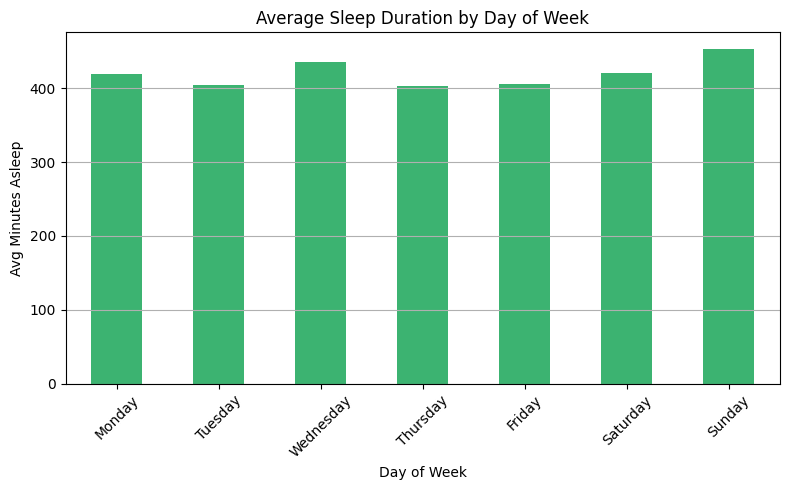

In [79]:
plt.figure(figsize=(8,5))
avg_sleep_by_day.plot(kind='bar', color='mediumseagreen')
plt.title('Average Sleep Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Minutes Asleep')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [83]:
# from this barchart we are able to say that people sleep more on Saturday and Sunday, the classic
# catchup sleep pattern.

In [89]:
# Working on a corrleation matrix to see the relationship in daily_activities

In [91]:
numeric_cols = [
    'TotalSteps', 'TotalDistance', 'VeryActiveMinutes',
    'FairlyActiveMinutes', 'LightlyActiveMinutes',
    'SedentaryMinutes', 'Calories'
]
# Correlation matrix
corr_matrix = df[numeric_cols].corr()
corr_matrix


,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
TotalSteps,1.000000,0.985369,0.667079,0.498693,0.569600,-0.327484,0.591568
TotalDistance,0.985369,1.000000,0.681297,0.462899,0.516300,-0.288094,0.644962
VeryActiveMinutes,0.667079,0.681297,1.000000,0.312420,0.051926,-0.164671,0.615838
FairlyActiveMinutes,0.498693,0.462899,0.312420,1.000000,0.148820,-0.237446,0.297623
LightlyActiveMinutes,0.569600,0.516300,0.051926,0.148820,1.000000,-0.437104,0.286718
SedentaryMinutes,-0.327484,-0.288094,-0.164671,-0.237446,-0.437104,1.000000,-0.106973
Calories,0.591568,0.644962,0.615838,0.297623,0.286718,-0.106973,1.000000


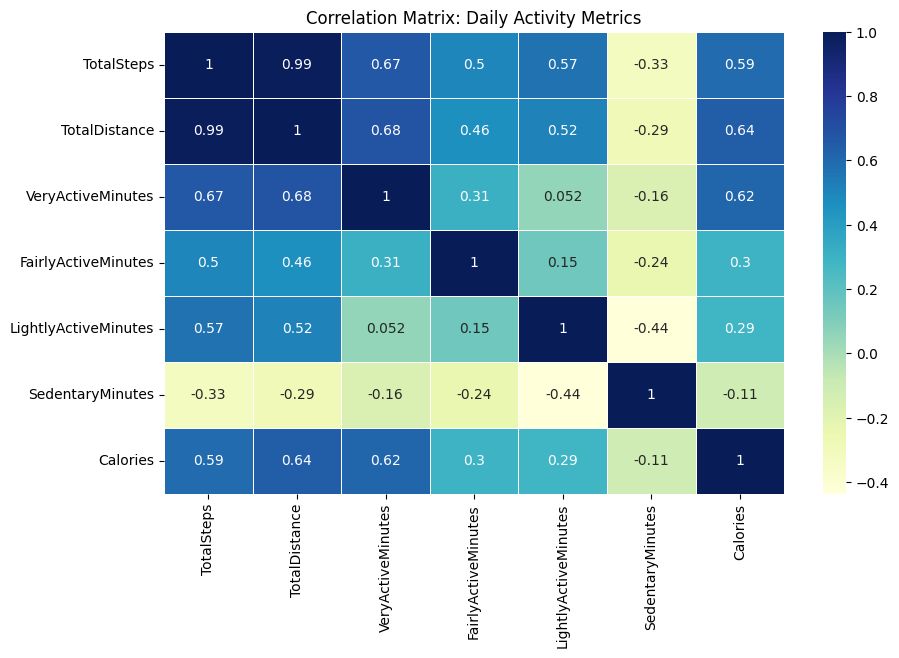

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title("Correlation Matrix: Daily Activity Metrics")
plt.show()


In [ ]:
# From this we can see that there is positive correlation between calories and total
# active minutes, total steps and total distance.

# There is a negative correlation between calories and sedentary minutes.

In [107]:
# Let's calculate sleep efficiency to understand how users sleep.

# Calculate Sleep Efficiency
sleepDay_df['SleepEfficiency'] = (sleepDay_df['TotalMinutesAsleep'] / sleepDay_df['TotalTimeInBed']) * 100

# Round to 2 decimal places
sleepDay_df['SleepEfficiency'] = sleepDay_df['SleepEfficiency'].round(2)

# Display a sample
sleepDay_df[['Id', 'SleepDay', 'TotalMinutesAsleep', 'TotalTimeInBed', 'SleepEfficiency']].head()

,Id,SleepDay,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
0,1503960366,2016-04-12,327,346,94.51
1,1503960366,2016-04-13,384,407,94.35
2,1503960366,2016-04-15,412,442,93.21
3,1503960366,2016-04-16,340,367,92.64
4,1503960366,2016-04-17,700,712,98.31


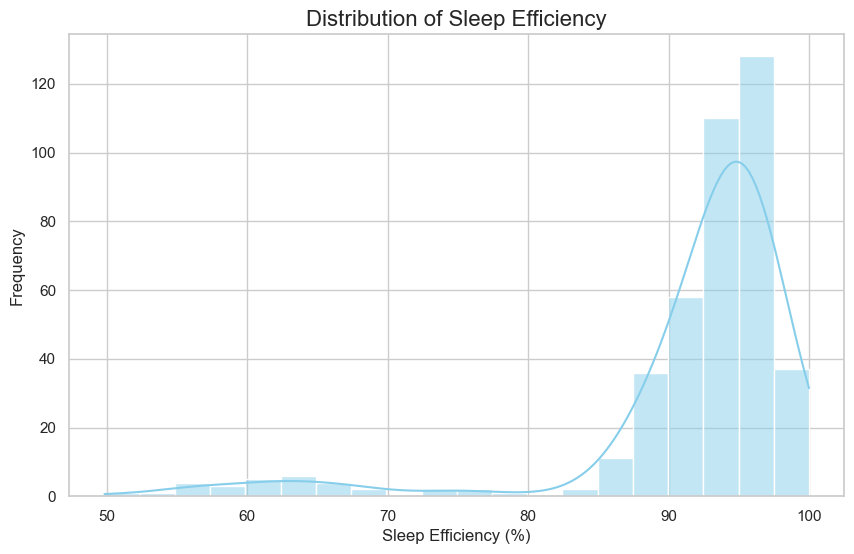

In [109]:
sns.set(style="whitegrid")

# Histogram of Sleep Efficiency
plt.figure(figsize=(10,6))
sns.histplot(sleepDay_df['SleepEfficiency'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sleep Efficiency', fontsize=16)
plt.xlabel('Sleep Efficiency (%)')
plt.ylabel('Frequency')
plt.show()

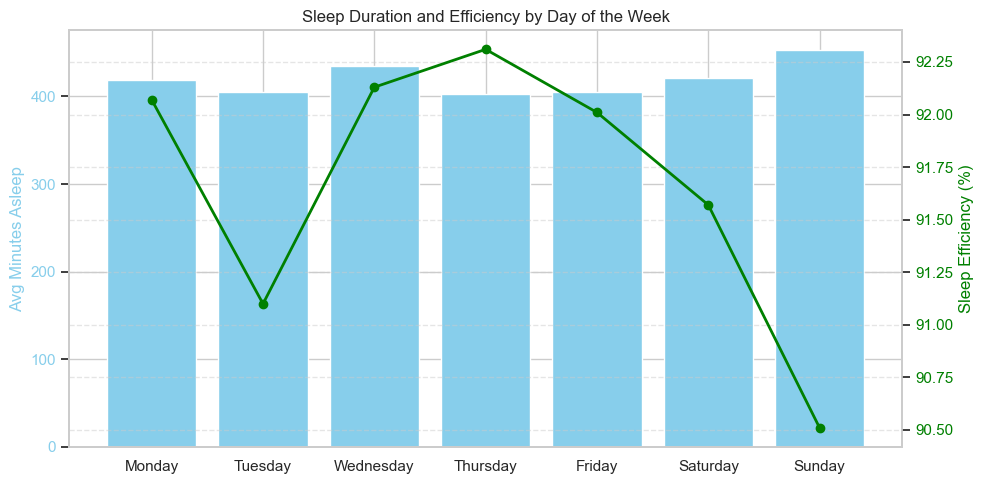

In [123]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for Avg Minutes Asleep
ax1.bar(avg_sleep_by_day.index, avg_sleep_by_day['TotalMinutesAsleep'],
        color='skyblue', label='Avg Minutes Asleep')
ax1.set_ylabel('Avg Minutes Asleep', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line plot for Sleep Efficiency
ax2 = ax1.twinx()
ax2.plot(avg_sleep_by_day.index, avg_sleep_by_day['SleepEfficiency'],
         color='green', marker='o', linewidth=2, label='Sleep Efficiency (%)')
ax2.set_ylabel('Sleep Efficiency (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Sleep Duration and Efficiency by Day of the Week')
fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
